In [13]:
import os
import sys
import cv2
import torch
import numpy as np
import onnxruntime
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt 

from modelscope import snapshot_download, Model
from modelscope.pipelines import pipeline
from modelscope.utils.constant import  Tasks

sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../external/facechain'))
# sys.path.append(os.path.abspath('/home/aliaagheis/mmcv'))
from constants import BASE_DIR

In [20]:
import gc
def clean_torch():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Inference Step by Step

In [12]:
from facechain.inference_inpaint_fact import *

/opt/conda/lib/python3.8/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


In [42]:
inpaint_img_path = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned_focused/Frame 27.png'
input_img_path = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned_focused/Frame 2.png'

def open_img_w_bg(image_path):
    img = Image.open(image_path).convert("RGBA")
    white_bg = Image.new("RGB", img.size, (255, 255, 255))
    white_bg.paste(img, mask=img.split()[3])
    return white_bg
    
inpaint_img = open_img_w_bg(inpaint_img_path).convert("RGB").resize((512, 512))
input_img = open_img_w_bg(input_img_path).convert('RGB').resize((512, 512))

In [43]:
# detect face
face_detection = pipeline(
            task=Tasks.face_detection,
            model='damo/cv_ddsar_face-detection_iclr23-damofd',
            model_revision='v1.1')

bbox = face_box = np.array(face_detection(inpaint_img)['boxes'][0]).astype(np.int16)

del face_detection
clean_torch()

2025-06-19 02:28:44,072 - modelscope - INFO - Use user-specified model revision: v1.1


2025-06-19 02:28:48,510 - modelscope - INFO - Use user-specified model revision: v1.1
2025-06-19 02:28:49,112 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
2025-06-19 02:28:49,113 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd.
2025-06-19 02:28:49,115 - modelscope - INFO - initialize model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
2025-06-19 02:28:49,154 - mmcv - INFO - initialize PAFPN with init_cfg {'type': 'Xavier', 'layer': 'Conv2d', 'distribution': 'uniform'}
2025-06-19 02:28:49,157 - mmcv - INFO - 
lateral_convs.0.conv.weight - torch.Size([16, 64, 1, 1]): 
XavierInit: gain=1, distribution=uniform, bias=0 
 
2025-06-19 02:28:49,158 - mmcv - INFO - 
lateral_convs.0.conv.bias - torch.Size([16]): 
The value is the same before and after calling `init_weights` of PAFPN  
 
2025

load checkpoint from local path: /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd/pytorch_model.pt


In [44]:
inpaint_img_large = np.copy(np.array(inpaint_img)[:, :, ::-1])
mask_large = np.ones_like(inpaint_img_large)
mask_large1 = np.zeros_like(inpaint_img_large)

h, w, _ = inpaint_img_large.shape

inpaint_img_large[bbox[1]:bbox[3], bbox[0]:bbox[2]] = 0
mask_large[bbox[1]:bbox[3], bbox[0]:bbox[2]] = 0

# crop face

face_ratio = 0.7
cropl = int(
    max(face_box[3] - face_box[1], face_box[2] - face_box[0])
    / face_ratio / 2)
cx = int((face_box[2] + face_box[0]) / 2)
cy = int((face_box[1] + face_box[3]) / 2)
cropup = min(cy, cropl)
cropbo = min(h - cy, cropl)
crople = min(cx, cropl)
cropri = min(w - cx, cropl)
inpaint_img = np.pad(
    inpaint_img_large[cy - cropup:cy + cropbo,
                      cx - crople:cx + cropri],
    ((cropl - cropup, cropl - cropbo),
     (cropl - crople, cropl - cropri), (0, 0)), 'constant')
inpaint_img = cv2.resize(inpaint_img, (512, 512))
inpaint_img = Image.fromarray(inpaint_img[:, :, ::-1])
mask_large1[cy - cropup:cy + cropbo, cx - crople:cx + cropri] = 1
mask_large = mask_large * mask_large1

In [45]:
w, h = input_img.size

w, h

(512, 512)

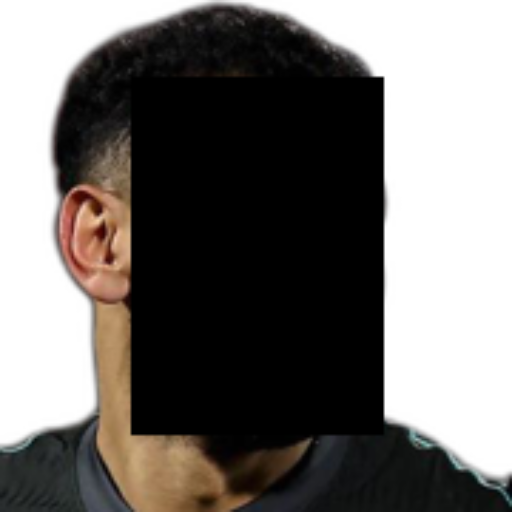

In [46]:
inpaint_img

# 1. Face Extraction

## 1.1 Fix Image Orientation

In [2]:
rot_bgr_id = 'Cherrytest/rot_bgr'
model_dir = snapshot_download(rot_bgr_id)
model_path = os.path.join(model_dir, 'rot_bgr.onnx')
ort_session = onnxruntime.InferenceSession(model_path, providers=['CUDAExecutionProvider'])

2025-06-16 21:07:17,527 - modelscope - WARNING - Model revision not specified, use revision: v1.0.0
/opt/conda/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:65: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CPUExecutionProvider'
  warnings.warn(


In [3]:
def softmax(x):
    x -= np.max(x, axis=0, keepdims=True)
    x = np.exp(x) / np.sum(np.exp(x), axis=0, keepdims=True)
    return x

def get_rot(image, ort_session):
    img_cv = cv2.cvtColor(np.asarray(image), cv2.COLOR_RGB2BGR)
    img_np = cv2.resize(img_cv, (224, 224)).astype(np.float32)
    img_clone = img_cv.copy().astype(np.uint8)
    
    mean = np.array([103.53, 116.28, 123.675], dtype=np.float32).reshape((1, 1, 3))
    norm = np.array([0.01742919, 0.017507, 0.01712475], dtype=np.float32).reshape((1, 1, 3))
    img_np = (img_np - mean) * norm
    
    img_nchw = torch.from_numpy(img_np).unsqueeze(0).permute(0, 3, 1, 2).numpy()
    ort_inputs = {ort_session.get_inputs()[0].name: img_nchw}

    logits = ort_session.run(None, ort_inputs)[0].reshape((-1,)) # [0, 90, 180, 270]
    rot_idx = np.argmax(logits)
    if rot_idx == 1:
        img_clone = cv2.transpose(img_clone)
        img_clone = np.flip(img_clone, 1)
        return Image.fromarray(cv2.cvtColor(img_clone, cv2.COLOR_BGR2RGB))
    elif rot_idx == 2:
        img_clone = cv2.flip(img_clone, -1)
        return Image.fromarray(cv2.cvtColor(img_clone, cv2.COLOR_BGR2RGB))
    elif rot_idx == 3:
        img_clone = cv2.transpose(img_clone)
        img_clone = np.flip(img_clone, 0)
        return Image.fromarray(cv2.cvtColor(img_clone, cv2.COLOR_BGR2RGB))
    else:
        return image

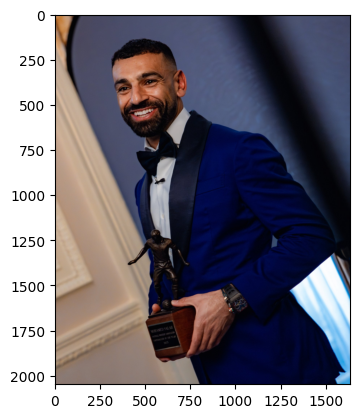

In [4]:
image_path = BASE_DIR / 'datasets/celebrities/mo_salah/raw/2.jpeg'
image = Image.open(image_path).convert('RGB')#.rotate(170).convert('RGB')

image_ = get_rot(image, ort_session)
plt.imshow(image_)

In [5]:
# import onnx

# model = onnx.load(model_path)
# print(onnx.helper.printable_graph(model.graph))

## 1.2 Facce Rotation

In [6]:
os.environ['MODELSCOPE_CACHE'] = '/mnt/workspace/.cache/modelscope/hub'

In [9]:
face_detection = pipeline(task=Tasks.face_detection, model='damo/cv_resnet50_face-detection_retinaface')

2025-06-16 21:19:19,528 - modelscope - WARNING - Model revision not specified, use revision: v2.0.2


2025-06-16 21:19:23,882 - modelscope - WARNING - Model revision not specified, use revision: v2.0.2
2025-06-16 21:19:24,368 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/hub/models/damo/cv_resnet50_face-detection_retinaface
2025-06-16 21:19:24,369 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/hub/models/damo/cv_resnet50_face-detection_retinaface.
2025-06-16 21:19:24,374 - modelscope - WARNING - No preprocessor field found in cfg.
2025-06-16 21:19:24,375 - modelscope - WARNING - No val key and type key found in preprocessor domain of configuration.json file.
2025-06-16 21:19:24,376 - modelscope - WARNING - Cannot find available config to build preprocessor at mode inference, current config: {'model_dir': '/mnt/workspace/.cache/modelscope/hub/models/damo/cv_resnet50_face-detection_retinaface'}. trying to build by task and model information.
2025-06-16 21:19:24,377 - modelscope - WARNING - Find task: face-detection, model 

In [10]:
result = face_detection(image_)

In [19]:
face_idx = np.argmax(result['scores'])

face_landmarks = np.array(result['keypoints'][face_idx]).reshape(5, 2)

face_landmarks

array([[377.05462646, 409.93615723],
       [525.34161377, 379.2612915 ],
       [448.95651245, 484.05801392],
       [416.70974731, 551.64196777],
       [554.42004395, 525.12194824]])

In [31]:
for idx in range(len(scores)):
    # Extract bbox
    bbox = result['boxes']  # format: [x1, y1, x2, y2]
    landmarks = face.get('keypoints')  # format: list of (x, y)

    # Draw on image
    draw = ImageDraw.Draw(image_)
    draw.rectangle(bbox, outline='red', width=3)

    if landmarks is not None:
        for (x, y) in landmarks:
            r = 2
            draw.ellipse([x - r, y - r, x + r, y + r], fill='blue')

KeyError: 'faces'

Found 1 faces


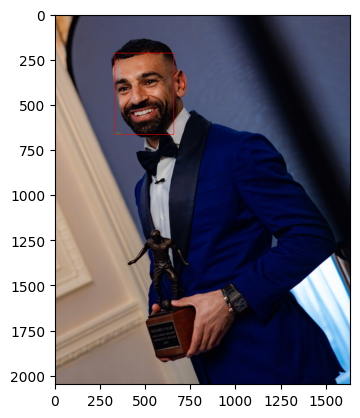

In [28]:
from modelscope.utils.cv.image_utils import draw_face_detection_result
from modelscope.preprocessors.image import LoadImage
img = LoadImage.convert_to_ndarray(str(image_path))
cv2.imwrite('srcImg.jpg', img)
img_draw = draw_face_detection_result('srcImg.jpg', result)
import matplotlib.pyplot as plt
plt.imshow(img_draw)

In [ ]:
from mmengine.config import Config
from mmengine.runner import load_checkpoint
from mmdet.models import build_detector
from modelscope.models.cv.face_detection.scrfd.mmdet_patch.datasets import RetinaFaceDataset
from modelscope.models.cv.face_detection.scrfd.mmdet_patch.datasets.pipelines import RandomSquareCrop
from modelscope.models.cv.face_detection.scrfd.mmdet_patch.models.backbones import ResNetV1e
from modelscope.models.cv.face_detection.scrfd.mmdet_patch.models.dense_heads import SCRFDHead
from modelscope.models.cv.face_detection.scrfd.mmdet_patch.models.detectors import SCRFD

/home/aliaagheis/miniconda3/envs/fast_env/lib/python3.12/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/home/aliaagheis/miniconda3/envs/fast_env/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


ImportError: cannot import name 'build_detector' from 'mmdet.models' (/home/aliaagheis/miniconda3/envs/fast_env/lib/python3.12/site-packages/mmdet/models/__init__.py)